In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from black_scholes.pinn.bs_pinn_nd import BlackScholesMultiAssetPINN
from black_scholes.tree.tree import BinomialTree
from config.bs_nd import *

from utility.plot import plot_price_heatmaps
from utility.continuation_prob import compute_continuation_probs, estimate_continuation_value_nd, continuation_normal

## Load models

### PINNs

In [2]:
seeds = range(105, 114)
pinns = []
for seed in seeds:
    pinn = BlackScholesMultiAssetPINN(model_config, seed=seed)
    pinn.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
    pinn.load(f'../../models/bs_pinn_nd/{seed}.pth')
    pinns.append(pinn)


### Binomial 1D reduction

In [3]:
cov_matrix = np.outer(sigmas, sigmas) * corr
r_1d = r * 2 + np.sum(np.tril(cov_matrix, k=-1))
sigma_1d = np.sqrt(np.sum(cov_matrix))

bt_1d = BinomialTree(K, r_1d, sigma_1d, T, n_steps=200)

## Compare PINN with binomial tree

### Heatmap of $f(0, S_1, S_2)$

In [4]:
resolution = 100
t = 0.0
S1 = np.linspace(0.0, 3.0, resolution)
S2 = np.linspace(0.0, 3.0, resolution)

S1_grid, S2_grid = np.meshgrid(S1, S2, indexing='ij')
t_grid = np.full(S1_grid.shape, t)

nn_prices_all = np.zeros((resolution, resolution, len(pinns)))
for k, pinn in enumerate(pinns):
    nn_prices_all[:, :, k] = pinn.predict(t_grid.flatten(), S1_grid.flatten(), S2_grid.flatten()).detach().numpy().reshape(S1_grid.shape)
nn_prices = np.mean(nn_prices_all, axis=2)

bt_prices = bt_1d.predict(t, (S1_grid * S2_grid).flatten()).reshape(S1_grid.shape)

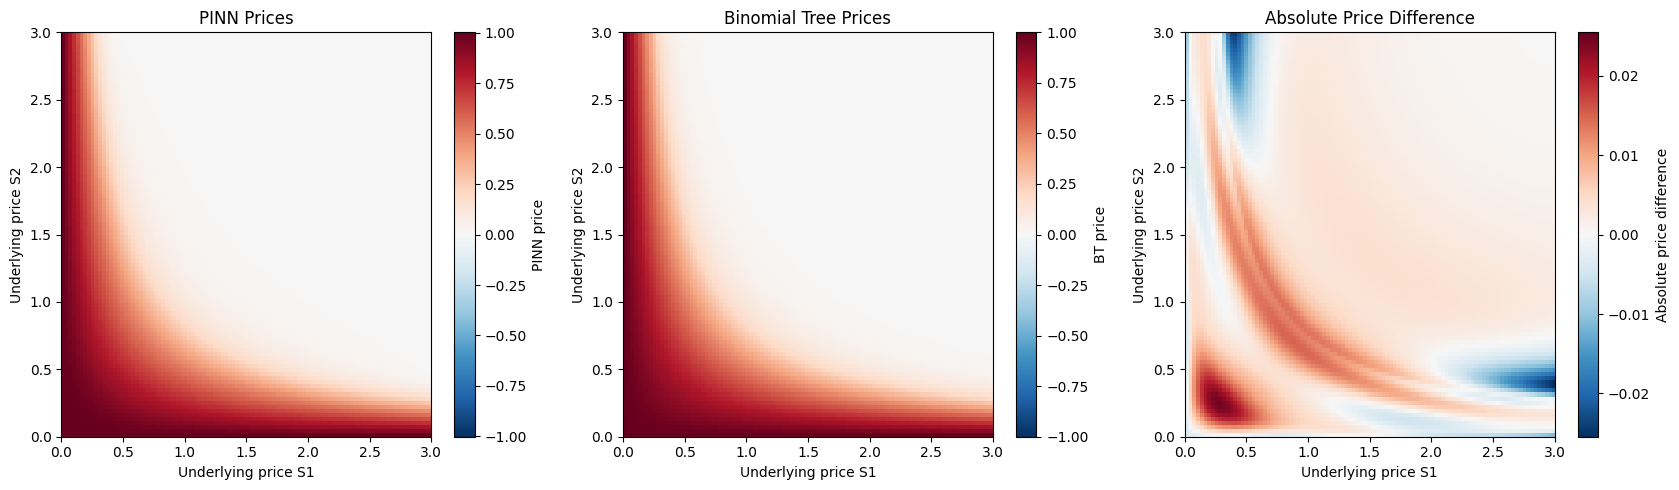

In [5]:
plot_price_heatmaps(
    prices1=nn_prices, prices2=bt_prices,
    xlabel='Underlying price S1', ylabel='Underlying price S2',
    title1='PINN Prices', title2='Binomial Tree Prices', title_diff='Absolute Price Difference',
    label1='PINN price', label2='BT price', label_diff='Absolute price difference',
    extent=[S1[0], S1[-1], S2[0], S2[-1]],
    save_path='../../plots/black_scholes/bs_pinn_nd_price_comparison.png'
)

### Slice $f(0, S_1, S_2)$ where $S_1S_2 = K$

In [6]:
target = K * 1

Smax = S_maxs[1] / target
S1s = np.linspace(1 / Smax, Smax, resolution)
S2s = target / S1s

nn_prices_all_atm = np.zeros((resolution, len(pinns)))
for k, pinn in enumerate(pinns):
    nn_prices_all_atm[:, k] = np.array([pinn.predict(0.0, S1, S2).item() for S1, S2 in zip(S1s, S2s)])
nn_prices_atm = np.mean(nn_prices_all_atm, axis=1)
bt_price = bt_1d.predict(0.0, target)

### Diagonal slice $f(t, K, K)$ varying $t$

In [7]:
ts = np.linspace(0, T-1e-4, resolution)

nn_prices_all_time = np.zeros((resolution, len(pinns)))
for k, pinn in enumerate(pinns):
    nn_prices_all_time[:, k] = pinn.predict(ts, K, K).detach().numpy().flatten()
nn_prices_time = np.mean(nn_prices_all_time, axis=1)

bt_prices_time = [bt_1d.predict(t, K) for t in ts]

### Plot the two together

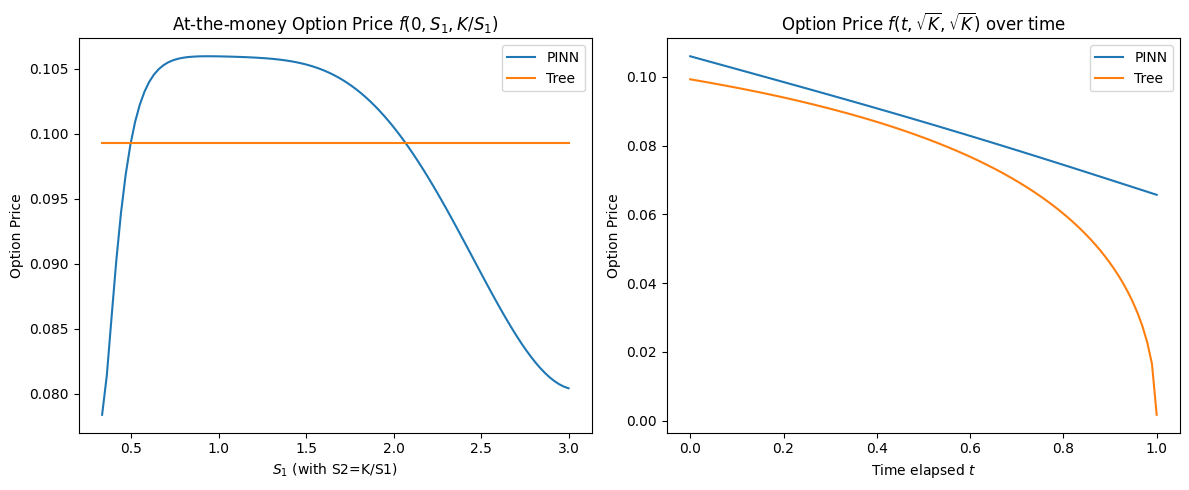

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(S1s, nn_prices_atm, label='PINN')
plt.plot(S1s, [bt_price] * len(S1s), label='Tree')
plt.xlabel('$S_1$ (with S2=K/S1)')
plt.ylabel('Option Price')
plt.title('At-the-money Option Price $f(0, S_1, K/S_1)$')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ts, nn_prices_time, label='PINN')
plt.plot(ts, bt_prices_time, label='Tree')
plt.legend()
plt.xlabel('Time elapsed $t$')
plt.ylabel('Option Price')
plt.title('Option Price $f(t, \sqrt{K}, \sqrt{K})$ over time')

plt.tight_layout()

plt.savefig('../../plots/black_scholes/bs_pinn_nd_price_comparison_line.png')
plt.show()

### Numerics at $f(0, \sqrt K, \sqrt K)$

In [9]:
nn_prices_all_initial_atm = [pinn.predict(0.0, np.sqrt(K), np.sqrt(K)).item() for pinn in pinns]
nn_price_initial_atm = np.mean(nn_prices_all_initial_atm)
nn_price_initial_atm_std = np.std(nn_prices_all_initial_atm)

standard_error = 1.96 * nn_price_initial_atm_std / np.sqrt(len(pinns))
print(f"PINN price at (0, sqrt(K), sqrt(K)): {nn_price_initial_atm:.4f} ± {standard_error:.4f} (95% CI)")

bt_initial_atm = bt_1d.predict(0.0, K)[0]
print("Binomial tree price at (0, sqrt(K), sqrt(K)):", bt_initial_atm)

relative_error_atm = abs(nn_price_initial_atm - bt_initial_atm) / bt_initial_atm
print(f"Relative error at (0, sqrt(K), sqrt(K)): {relative_error_atm:.4%}")

PINN price at (0, sqrt(K), sqrt(K)): 0.1060 ± 0.0048 (95% CI)
Binomial tree price at (0, sqrt(K), sqrt(K)): 0.09925510091241853
Relative error at (0, sqrt(K), sqrt(K)): 6.7524%


## Continuation probabilities

### $S_1$-$S_2$ cross section

In [10]:
resolution = 100
S1s = np.linspace(0, 3, resolution)
S2s = np.linspace(0, 3, resolution)

intrinsics = np.maximum(K - (S1s[:, None] * S2s[None, :]), 0) + 1e-9

In [11]:
nn_continuation_values_all = np.zeros((resolution, resolution, len(pinns)))
bt_continuation_values = np.zeros((resolution, resolution))

for i, S1 in enumerate(S1s):
    for j, S2 in enumerate(S2s):
        S = torch.tensor([S1, S2], dtype=torch.float32)
        bt_continuation_values[i, j] = bt_1d.predict(0.0, S1 * S2, continuation_value=True)[0]
        for k, pinn in enumerate(pinns):
            nn_continuation_values_all[i, j, k] = estimate_continuation_value_nd(pinn.model, 0.0, S, r, sigmas, corr, n_paths=100, h=0.01, seed=42)

nn_continuation_values = np.mean(nn_continuation_values_all, axis=2)
nn_continuation_values_std = np.std(nn_continuation_values_all, axis=2, ddof=1)


In [12]:
bt_continuation_probs = np.where(bt_continuation_values > intrinsics, 1.0, 0.0)
nn_continuation_probs_sigmoid = compute_continuation_probs(nn_continuation_values, intrinsics, eps=0.1, one=0.99, shift=0)
nn_continuation_probs_gaussian = continuation_normal(nn_continuation_values, nn_continuation_values_std, intrinsics)

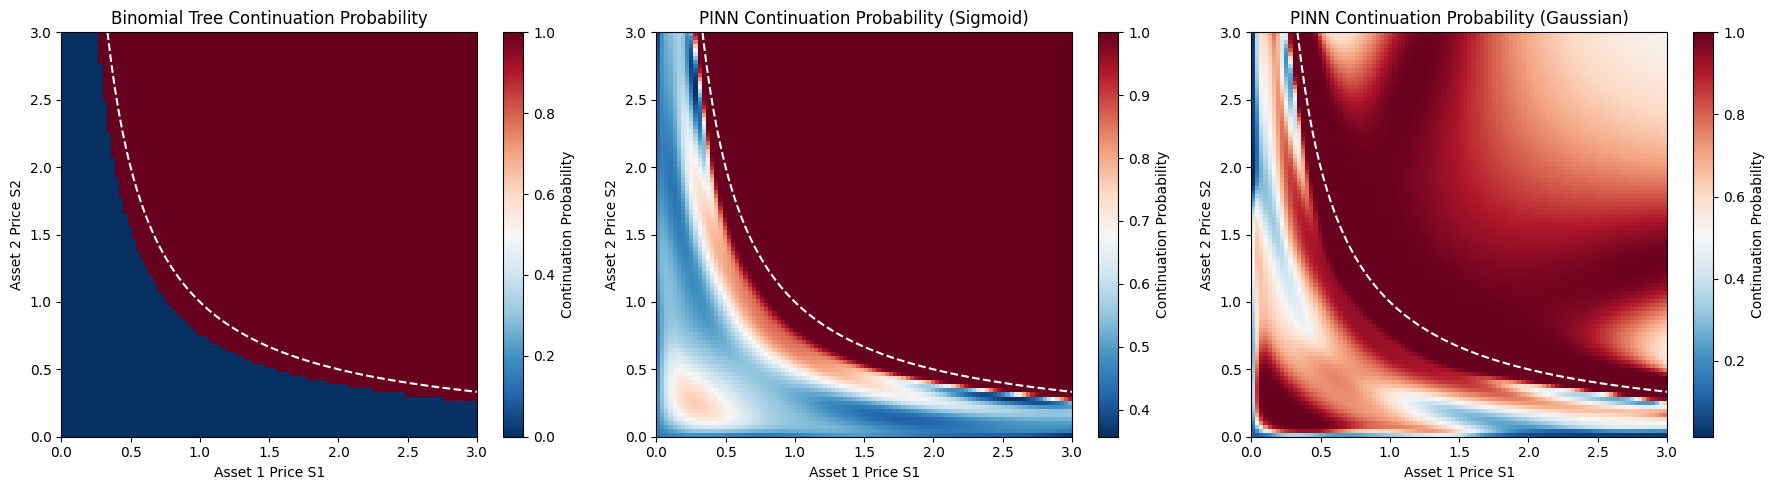

In [13]:
# Plot S_1 times S_2 = K contour
S1_contour = np.linspace(K / Smax, Smax, resolution)
S2_contour = target / S1_contour

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(bt_continuation_probs, extent=[S1s[0], S1s[-1], S2s[0], S2s[-1]], origin='lower', aspect='auto', cmap='RdBu_r')
plt.plot(S1_contour, S2_contour, color='white', linestyle='--')
plt.colorbar(label='Continuation Probability')
plt.xlabel('Asset 1 Price S1')
plt.ylabel('Asset 2 Price S2')
plt.title('Binomial Tree Continuation Probability')

plt.subplot(1, 3, 2)
plt.imshow(nn_continuation_probs_sigmoid, extent=[S1s[0], S1s[-1], S2s[0], S2s[-1]], origin='lower', aspect='auto', cmap='RdBu_r')
plt.plot(S1_contour, S2_contour, color='white', linestyle='--')
plt.colorbar(label='Continuation Probability')
plt.xlabel('Asset 1 Price S1')
plt.ylabel('Asset 2 Price S2')
plt.title('PINN Continuation Probability (Sigmoid)')


plt.subplot(1, 3, 3)
plt.imshow(nn_continuation_probs_gaussian, extent=[S1s[0], S1s[-1], S2s[0], S2s[-1]], origin='lower', aspect='auto', cmap='RdBu_r')
plt.plot(S1_contour, S2_contour, color='white', linestyle='--')

plt.colorbar(label='Continuation Probability')
plt.xlabel('Asset 1 Price S1')
plt.ylabel('Asset 2 Price S2')
plt.title('PINN Continuation Probability (Gaussian)')

plt.tight_layout()

plt.savefig('../../plots/black_scholes/bs_nd_continuation_probs.png')
plt.show()

### $S_1 = S_2$

In [14]:
ts = np.linspace(0, T-1e-4, resolution)
S1s_time = np.linspace(0, np.sqrt(K), resolution)

intrinsics_time = np.maximum(K - (S1s_time[:, None] * S1s_time[None, :]), 0) + 1e-9

nn_continuation_values_time_all = np.zeros((resolution, resolution, len(pinns)))
bt_continuation_values_time = np.zeros((resolution, resolution))

for i, t in enumerate(ts):
    bt_continuation_values_time[i, :] = bt_1d.predict(t, np.square(S1s_time), continuation_value=True)
    for j, S1 in enumerate(S1s_time):
        S = torch.tensor([S1, S1], dtype=torch.float32)
        for k, pinn in enumerate(pinns):
            nn_continuation_values_time_all[i, j, k] = estimate_continuation_value_nd(pinn.model, t, S, r, sigmas, corr, n_paths=100, h=0.01, seed=42)
nn_continuation_values_time = np.mean(nn_continuation_values_time_all, axis=2)
nn_continuation_values_time_std = np.std(nn_continuation_values_time_all, axis=2, ddof=1)


In [15]:
bt_continuation_probs_time = np.where(bt_continuation_values_time > intrinsics_time, 1.0, 0.0)
nn_continuation_probs_time_sigmoid = compute_continuation_probs(nn_continuation_values_time, intrinsics_time, eps=0.1, one=0.99, shift=0)
nn_continuation_probs_time_gaussian = continuation_normal(nn_continuation_values_time, nn_continuation_values_time_std, intrinsics_time)

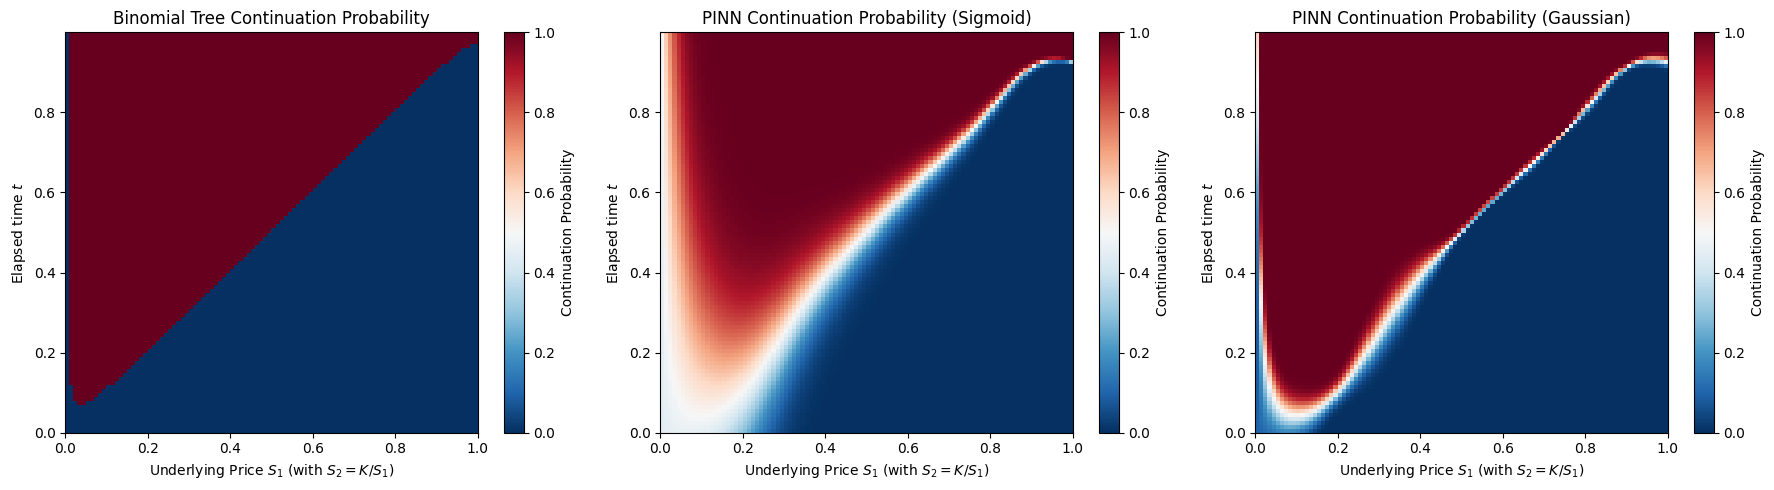

In [16]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(bt_continuation_probs_time, extent=[S1s_time[0], S1s_time[-1], ts[0], ts[-1]], origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Continuation Probability')
plt.xlabel('Underlying Price $S_1$ (with $S_2=K/S_1$)')
plt.ylabel('Elapsed time $t$')
plt.title('Binomial Tree Continuation Probability')

plt.subplot(1, 3, 2)
plt.imshow(nn_continuation_probs_time_sigmoid, extent=[S1s_time[0], S1s_time[-1], ts[0], ts[-1]], origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Continuation Probability')
plt.xlabel('Underlying Price $S_1$ (with $S_2=K/S_1$)')
plt.ylabel('Elapsed time $t$')
plt.title('PINN Continuation Probability (Sigmoid)')


plt.subplot(1, 3, 3)
plt.imshow(nn_continuation_probs_time_gaussian, extent=[S1s_time[0], S1s_time[-1], ts[0], ts[-1]], origin='lower', aspect='auto', cmap='RdBu_r')

plt.colorbar(label='Continuation Probability')
plt.xlabel('Underlying Price $S_1$ (with $S_2=K/S_1$)')
plt.ylabel('Elapsed time $t$')
plt.title('PINN Continuation Probability (Gaussian)')

plt.tight_layout()

plt.savefig('../../plots/black_scholes/bs_nd_continuation_probs_time.png')
plt.show()